# Question 3: SMB Bundle Dashboard

## Assignment

<!-- Original Q3 assignment prompt from `Business Case for BA 2026 - SMB Bundles.pdf`. Do not edit unless specifically requested. -->

> **Question 3: How do we monitor the sales?**
>
> Flashforward to after the launch of the SMB Bundles. Thanks to your outreach prioritization we have done several subsequent batches of calls, and bundle registrations have been coming in. In the third dataset you can find an overview of SMB sellers from both SYI and Pro, showing which bundle they purchased, with a start and end date.
>
> As a promotion, the first 28 days are for free. After that they pay:
>
> - €19.99 per 4 weeks for a Basic bundle
> - €49.99 per 4 weeks for a Plus bundle
>
> Every seller can only get a discount once. They can stop their bundle, or switch to another one at any point in the month. For this business case, assume they immediately pay for the full 4 weeks (unless it’s their first bundle ever and thus get a discount), and do not get a refund for any time left in their previous bundle.
>
> Design and present a dashboard that will help you show the impact of our Bundle introduction, and any other important analysis or metrics. The dashboard should both be useful at the launch and at the later stages. Use the data that is available to already fill parts of your dashboard design, while clearly stating what other data you would need to complete your view.

`## 0. Data Structure

In [1]:
import importlib

from IPython.display import Markdown, display

import functions

functions = importlib.reload(functions)
pd = functions.pd
plt = functions.plt

functions.set_plot_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.1f}".format)


In [2]:
dashboard = functions.q3_dashboard_data()

bundle_df = dashboard["bundle_df"]
launch_start = dashboard["launch_start"]
dashboard_reference_date = dashboard["dashboard_reference_date"]
seller_fields = dashboard["seller_fields"]
weekly_metrics = dashboard["weekly_metrics"]
revenue_4w = dashboard["revenue_4w"]
revenue_by_bundle = dashboard["revenue_by_bundle"]
registrations_4w = dashboard["registrations_4w"]
cohort_metrics_28d = dashboard["cohort_metrics_28d"]
segment_metrics = dashboard["segment_metrics"]


In [3]:
print(f"Dashboard reference date: {dashboard_reference_date:%Y-%m-%d}")
print(f"Launch start date: {launch_start:%Y-%m-%d}")

display(functions.q3_structure_summary(bundle_df, dashboard_reference_date))
display(functions.q3_distribution_summary(bundle_df))


Dashboard reference date: 2025-04-29
Launch start date: 2024-02-29


,Metric,Value
0,Rows,"8,830"
1,Unique sellers,"4,076"
2,Start date range,2024-02-29 to 2025-04-29
3,Finite end date range,2024-03-04 to 2025-04-29
4,Open-ended rows,"4,094"
5,Missing values,0
6,Duplicate rows,0
7,Sellers with potential overlapping intervals,18


,Field,Value,Rows
0,Customer type,SYI,6802
1,Customer type,Pro,2028
2,Bundle,Basic,3777
3,Bundle,No bundle,2728
4,Bundle,Plus,2325


### 0.1 EDA Snapshot

**Purpose:** summarize the dataset facts that most affect dashboard interpretation.

**Scope:** this is a focused EDA for dashboard design, not a full exploratory analysis.

In [4]:
display(
    functions.q3_short_eda_summary(
        bundle_df,
        seller_fields,
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
    )
)


,Metric,Value
0,First bundle starters,"4,076"
1,Basic-first share,68.5%
2,Plus-first share,31.5%
3,Peak weekly registrations,432 in week of 2024-04-01
4,Latest active paid sellers,"2,709"
5,Latest active trial sellers,0
6,Current no-bundle sellers,"1,367"
7,Current Plus share of paid base,40.9%
8,Sellers with multiple bundle periods,"1,545"
9,Sellers using both Basic and Plus,"1,042"


### 0.2 Customer Type Deep Dive

**Finding:** customer type changes the size of the opportunity, but it does not strongly separate bundle quality in this file.

**Evidence:** Pro is a smaller group and starts slightly more often on Plus, while paid Plus share and no-bundle share are similar to SYI.

**Why it matters:** keep customer type as a dashboard filter, but use it as supporting context rather than the main steering signal.

In [5]:
display(functions.q3_customer_type_eda_display_table(bundle_df, seller_fields))

,Customer type,Bundle starters,Basic-first share,Plus-first share,Active paid sellers,Plus share of active paid sellers,Current no-bundle share,Multiple bundle-period share,Used Basic and Plus share
0,SYI,"3,137",69.2%,30.8%,"2,093",40.9%,33.3%,38.1%,26.1%
1,Pro,939,66.1%,33.9%,616,40.7%,34.4%,37.3%,23.7%


In [6]:
display(Markdown(functions.q3_customer_type_insights_markdown(bundle_df, seller_fields)))

- **Pro sellers are a smaller part of the file**  
  Evidence: Pro: 939 starters; SYI: 3,137 starters.  
  Interpretation: Customer type matters for sizing, but not necessarily for quality.
- **Pro starts slightly more often on Plus**  
  Evidence: Plus-first share: Pro 33.9%; SYI 30.8%.  
  Interpretation: This is directionally useful for positioning, but the gap is modest.
- **Paid mix is nearly the same**  
  Evidence: Paid Plus share: Pro 40.7%; SYI 40.9%.  
  Interpretation: Customer type alone does not strongly separate monetization quality.
- **No-bundle share is also similar**  
  Evidence: No-bundle share: Pro 34.4%; SYI 33.3%.  
  Interpretation: Customer type is not a strong churn/status signal in this dataset.

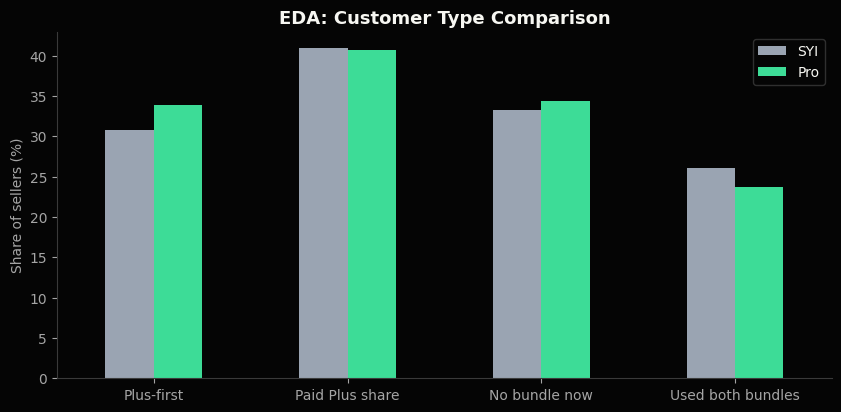

In [7]:
functions.plot_q3_customer_type_comparison(bundle_df, seller_fields)
plt.show()

### 0.3 Launch Demand Was Front-Loaded

**Finding:** registrations spiked early after launch, then settled into a much lower run-rate.

**Evidence to inspect:** weekly first-bundle registrations, with the peak week highlighted.

**Why it matters:** later dashboard views should focus less on raw launch demand and more on paid-base retention.

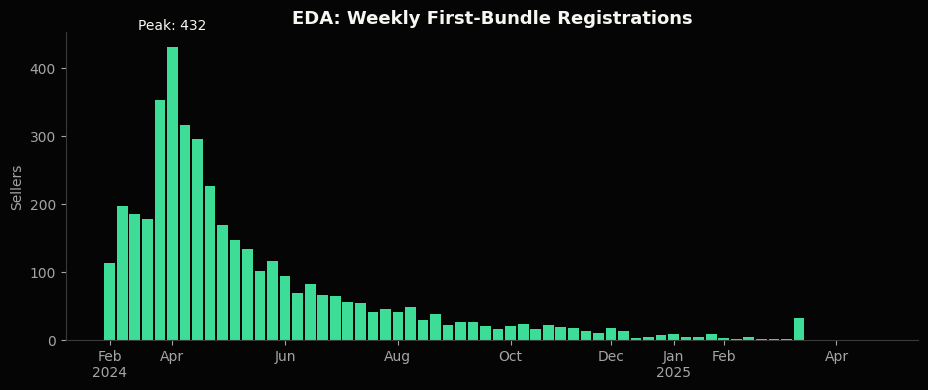

In [8]:
functions.plot_q3_eda_launch_demand(weekly_metrics)
plt.show()


### 0.4 Basic Is the Main Entry Bundle, Plus Matters for Monetization

**Finding:** most sellers start on Basic, but Plus represents a larger share of the current paid base than of first starts.

**Evidence to inspect:** first-bundle mix versus current active paid bundle mix.

**Why it matters:** Basic appears to drive adoption; Plus share is the monetization-quality signal.

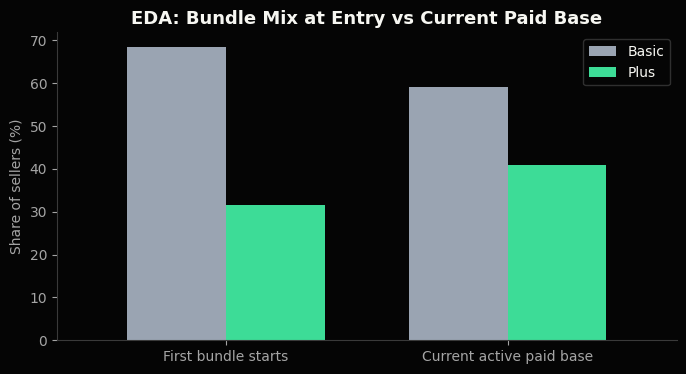

In [9]:
functions.plot_q3_eda_bundle_mix_shift(seller_fields)
plt.show()


### 0.5 Current Status Includes Paid Bundles and No-Bundle Intervals

**Finding:** many sellers who once started a bundle now have a current `No bundle` interval.

**Evidence to inspect:** current status of all sellers who ever started a bundle.

**Why it matters:** `No bundle` is part of this interval dataset. It means the seller is currently not on Basic or Plus; it does not mean the seller is missing from the file.

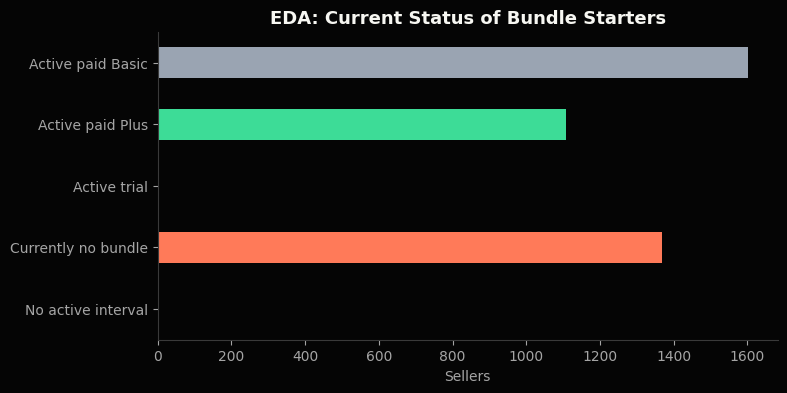

In [10]:
functions.plot_q3_eda_current_status(seller_fields)
plt.show()


### 0.6 Bundle Status Over Time

**Finding:** seller status shifts from no bundle into Basic and Plus after launch.

**Evidence to inspect:** weekly status of all unique sellers in this file.

**Why it matters:** this shows the size of the paid bundle base and the no-bundle pool in the same view.

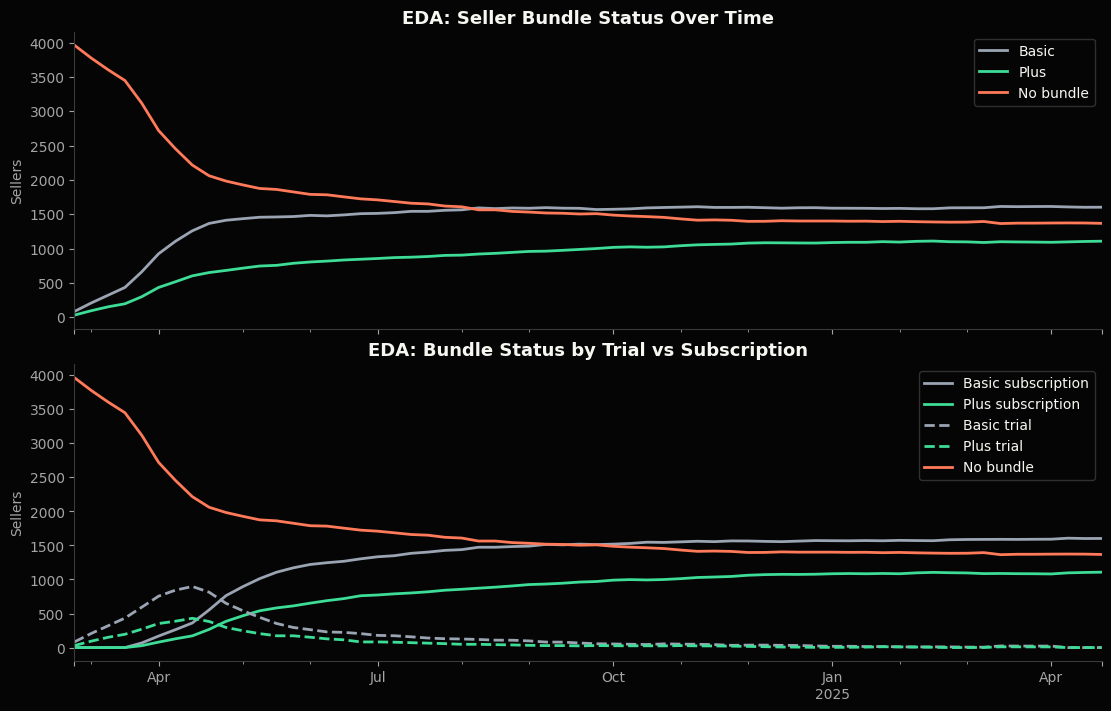

In [11]:
functions.plot_q3_eda_bundle_status_timeseries(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
)
plt.show()


### 0.7 Open-Ended Means Still Active

**Finding:** many rows end on `2099-12-31`.

**Evidence:** open-ended rows by bundle type.

**Meaning:** `2099-12-31` is a placeholder. It means the bundle is still active, not that it really ends in 2099.

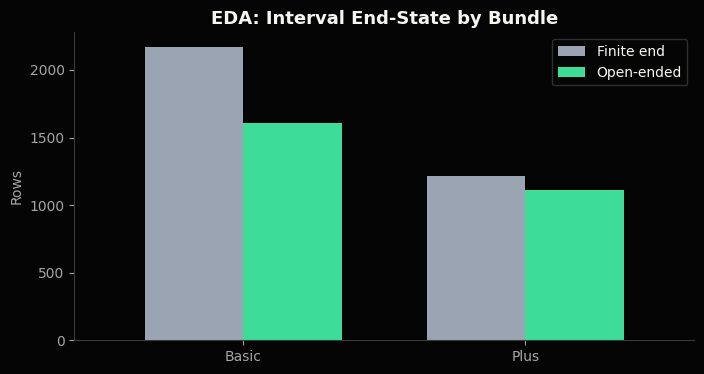

In [12]:
functions.plot_q3_eda_open_ended_intervals(bundle_df)
plt.show()


### 0.8 Repeat Bundle Periods and Switching Are Common

**Finding:** many sellers have multiple bundle periods, and a meaningful subset used both Basic and Plus.

**Evidence to inspect:** bundle-period count distribution and switching indicators.

**Why it matters:** a seller can have several rows without switching bundles. Dashboard metrics should be seller-level and period-aware.

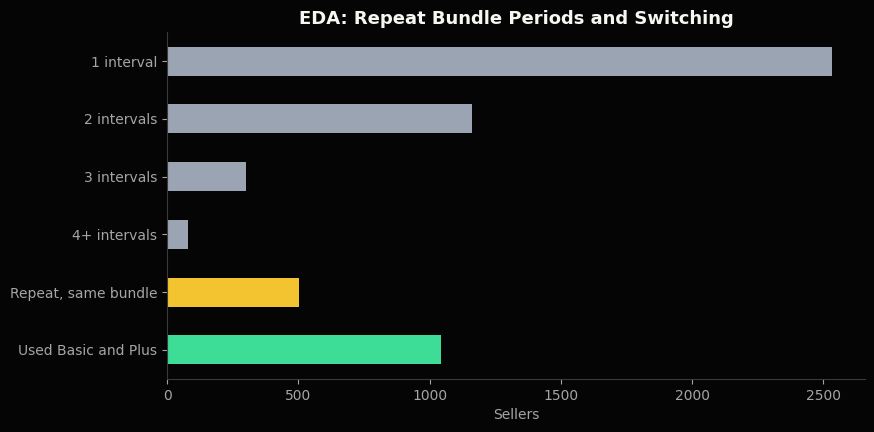

In [13]:
functions.plot_q3_eda_interval_complexity(bundle_df)
plt.show()


## 1. Sales Overview

**Business question:** are SMB Bundles gaining commercial traction after launch?

**Dashboard view:** demand, monetized adoption, trial pipeline, modeled revenue, and Plus mix over time.

**Looker controls:** use filter controls for date range, customer type, and bundle. Use breakdown dimensions for bundle and customer type when drilling into a time-series.

**What to read first:** the KPI strip uses the latest seller snapshot and latest complete 4-week periods where period completeness matters.

**Limitation:** revenue is modeled from bundle intervals and list prices. It is not actual invoiced or collected revenue.

### 1.1 KPI Snapshot

Core dashboard readout using the latest seller snapshot and latest complete 4-week periods where period completeness matters.

In [14]:
display(
    functions.q3_sales_kpis(
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
        registrations_4w,
    )
)


,KPI,Value
0,Reference date,2025-04-29
1,Active paid sellers,"2,709 (+0% w/w)"
2,Active trial sellers,0 (+0% w/w)
3,New registrations in latest complete 4wk period,35 (+133% vs prev 4wk)
4,Plus share of active paid sellers,40.9% (+0.1pp w/w)
5,Modeled revenue in latest complete 4wk period,"€88,323 (+0% vs prev 4wk)"


### 1.2 Weekly New Registrations

**Business question:** is launch demand growing, stable, or fading?

**What we measure:** sellers whose first-ever Basic or Plus bundle starts in each week.

**What the chart shows:** total demand over time, plus a by-bundle breakdown.

**Looker controls:** filter by date range, customer type, and bundle. Breakdown dimensions: bundle, customer type.

**Why it matters:** registrations are the earliest signal of sales traction.

**Limitation:** registrations do not prove paid adoption because the first 28 days are free.

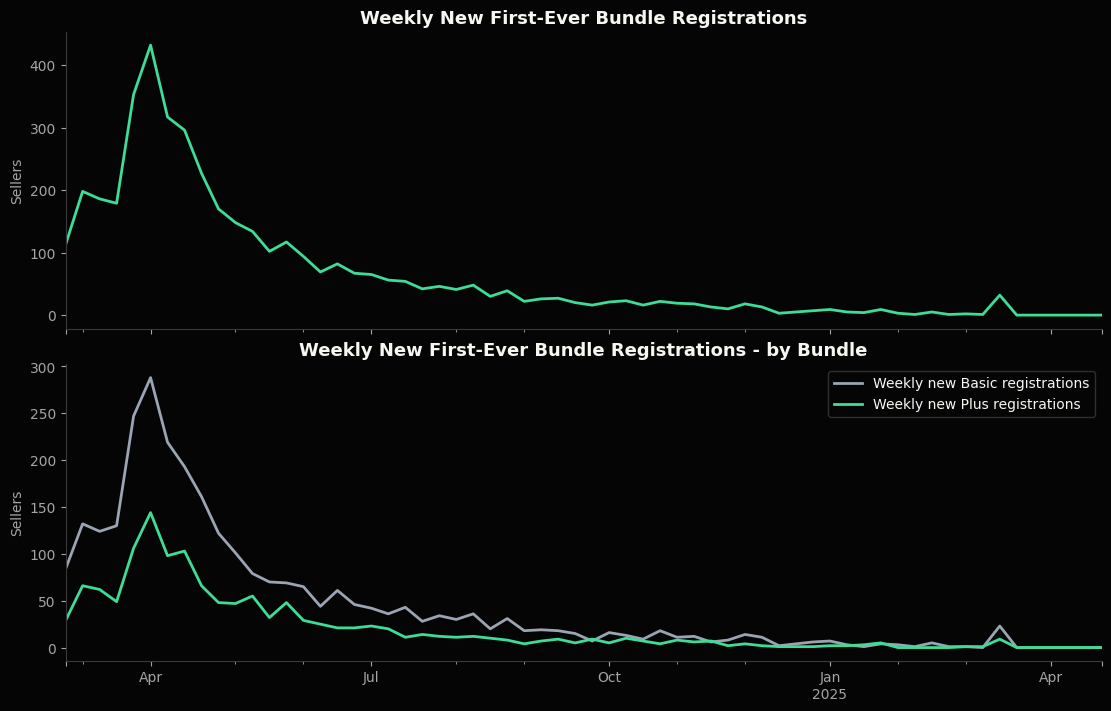

In [15]:
functions.plot_q3_weekly_new_registrations(weekly_metrics)
plt.show()


### 1.3 Active Bundle Sellers

**Business question:** is the paid base building after the free trial?

**What we measure:** active sellers, split into paid sellers and trial sellers.

**What the chart shows:** the first plot shows total paid versus trial sellers; the second plot adds the by-bundle breakdown. Solid lines are paid sellers after day 28; dashed lines are trial sellers still inside the first 28 days.

**Looker controls:** filter by date range, customer type, and bundle. Breakdown dimensions: bundle, paid/trial status, customer type.

**Why it matters:** this combines the monetized base and near-term paid pipeline in one view.

**Limitation:** active status is based on registration intervals, not payment collection records.

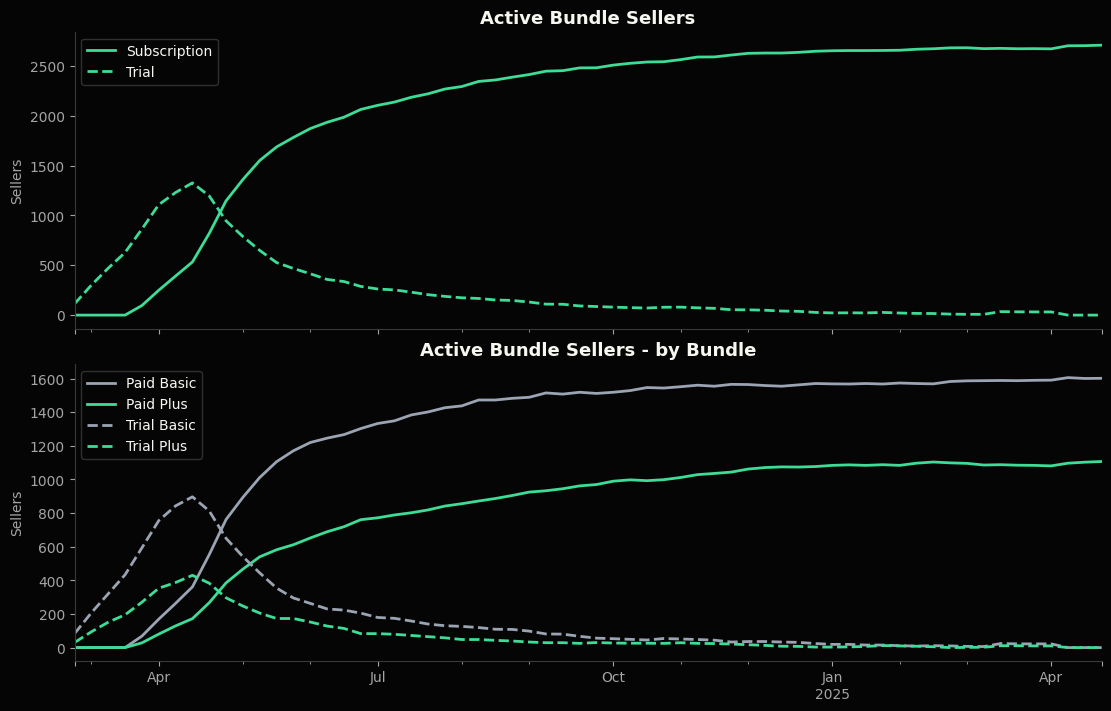

In [16]:
functions.plot_q3_active_bundle_sellers(weekly_metrics)
plt.show()

### 1.4 Modeled Paid Revenue

**Business question:** is monetized adoption translating into subscription revenue?

**What we measure:** modeled paid revenue based on the current registrations dataset, bundle prices, free-trial timing, and the no-refund switching assumption.

**What the chart shows:** 4-week modeled revenue periods anchored to launch. The final point is kept but marked as incomplete if the period is only partially observed.

**Looker controls:** filter by date range, customer type, and bundle. Breakdown dimensions: bundle, customer type.

**Why it matters:** this is the cleanest commercial value proxy available in the current dataset.

**Limitation:** this is modeled paid revenue, not actual invoiced or collected revenue, and not net incremental revenue.

,period_start,modeled_paid_revenue_eur,paid_billing_events
8,2024-10-10,"€84,963","2,670"
9,2024-11-07,"€87,303","2,727"
10,2024-12-05,"€87,573","2,721"
11,2025-01-02,"€88,243","2,738"
12,2025-01-30,"€88,723","2,744"
13,2025-02-27,"€88,073","2,734"
14,2025-03-27,"€88,323","2,745"
15,2025-04-24,"€21,044",646


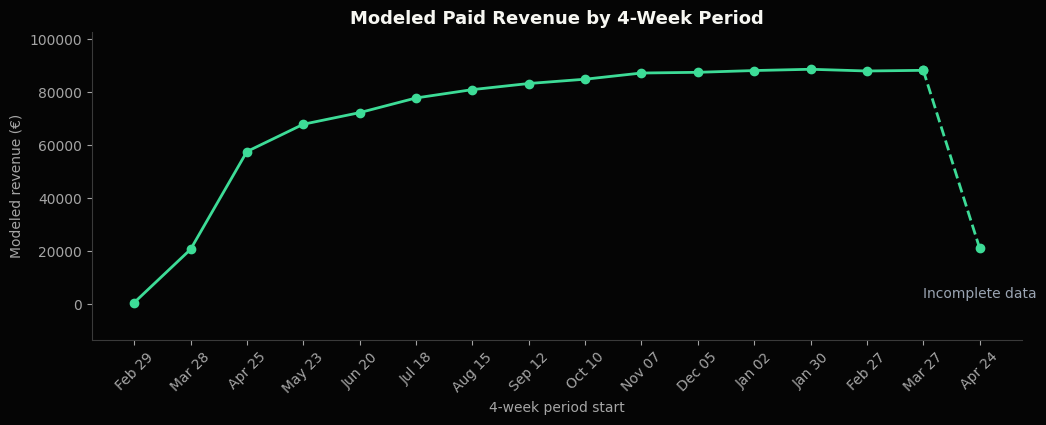

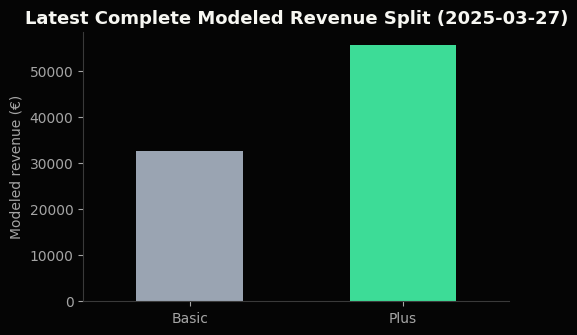

In [17]:
display(functions.q3_revenue_display_table(revenue_4w))

functions.plot_q3_modeled_revenue(revenue_4w, dashboard_reference_date)
plt.show()

functions.plot_q3_latest_revenue_by_bundle(revenue_by_bundle, dashboard_reference_date)
plt.show()


### 1.5 Plus Share

**Business question:** is adoption shifting toward the higher-priced bundle?

**What we measure:** active paid Plus sellers divided by all active paid bundle sellers.

**What the chart shows:** the paid mix between Plus and Basic over time.

**Looker controls:** filter by date range and customer type. Breakdown dimension: customer type.

**Why it matters:** Plus share measures monetization quality, not just adoption volume.

**Limitation:** this does not explain why sellers choose Plus; category, spend, and seller-size data would be needed.

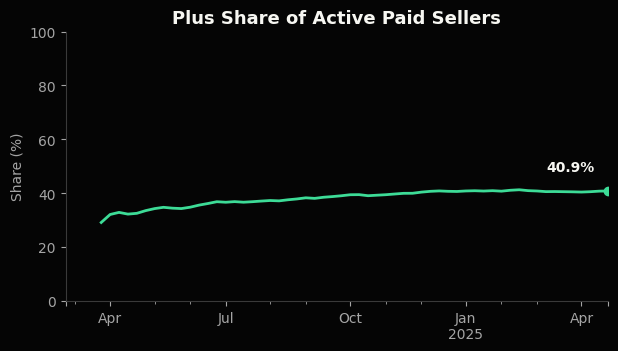

In [18]:
functions.plot_q3_plus_share(weekly_metrics)
plt.show()


## 2. Customer Quality

**Business question:** are registrations turning into retained paid customers?

**Dashboard view:** cohort health and segment diagnosis using only fields available in the registrations file.

**What to read first:** cohort rows define who is grouped together; maturity columns define how long those sellers have had to prove paid quality.

**Limitation:** this is early subscription quality only. It does not measure seller LTV or marketplace outcomes.

### 2.1 Cohort Health

**Business question:** do cohorts remain active paid after the free trial and later billing cycles?

**Cohort aggregation:** rows group sellers whose first Basic or Plus bundle started in the same 28-day window from launch.

**Cohort maturity:** 4wk, 8wk, 12wk, 16wk, 20wk, and 24wk are measured relative to each seller's own first bundle start. Blank cells are immature checkpoints, not zero conversion.

**What the heat-map shows:** darker cells indicate stronger active paid rates within the maturity columns.

**Limitation:** changes across cohorts at the same maturity can reflect seller mix, launch targeting, or small-sample noise. This dataset does not isolate the cause.

In [19]:
display(functions.q3_cohort_heatmap_table(cohort_metrics_28d))

### 2.2 Segmentation Analysis

**Business question:** which seller segments look stronger in the current dashboard snapshot?

**What we measure now:** registrations, 4wk paid conversion, Plus share, active paid sellers, and current no-bundle share.

**How to read it:** this is a snapshot comparison across segments, not a time-series deep dive. For segment movement over time, use the Sales Overview charts with filter controls and breakdown dimensions.

**Current cuts:** customer type, first bundle type, and current bundle status.

**Potential cuts:** the merge table keeps only the high-value idea and why it helps. These merges are not implemented with the current Q3 file.

In [20]:
display(functions.q3_segment_display_table(segment_metrics))

display(Markdown(functions.q3_markdown_table(functions.q3_segment_enrichment_opportunities())))

,Segment,Segment value,Registrations,Day-28 paid conversion,Plus share of active paid sellers,Active paid sellers,Current no-bundle share
0,Current bundle status,Basic,"1,602",93.4%,0.0%,"1,602",0.0%
1,Current bundle status,No bundle,"1,367",83.3%,,0,100.0%
2,Current bundle status,Plus,"1,107",90.2%,100.0%,"1,107",0.0%
3,Customer type,SYI,"3,137",89.1%,40.9%,"2,093",33.3%
4,Customer type,Pro,939,89.5%,40.7%,616,34.4%
5,First bundle type,Basic-first,"2,791",89.4%,25.5%,"1,845",33.9%
6,First bundle type,Plus-first,"1,285",88.7%,73.6%,864,32.8%


| Potential merge | Why it helps |
| --- | --- |
| SMB likelihood score | Separates likely business sellers from lighter consumer-like sellers. |
| Outreach readiness score | Shows whether sales-prioritized sellers convert and retain better. |
| Historical spend tier | Distinguishes high-value sellers from low-spend adopters. |
| Seller size / activity tier | Identifies whether bundles work better for large or small sellers. |
| Pro performance tier | Separates Pro sellers with real traffic from Pro sellers with low engagement. |
| Seller outcome tier | Shows whether bundles create value for sellers, not only platform revenue. |
| Outreach batch / channel | Connects launch execution to registration and paid conversion quality. |

#### Segmentation Mockup

**Purpose:** show how merged segment data could highlight sharp changes in bundle performance and health.

**What the mockup adds:** recent segment-level movement that would be hard to see from the overall Sales Overview trend.

**How to use:** keep Sales Overview as the time-series view. Use this module to identify which segment needs action now.

**Important:** the chart below uses dummy data only. It demonstrates the intended dashboard module, not current measured results.

In [21]:
display(Markdown(functions.q3_markdown_table(functions.q3_segment_mockup_descriptions())))

| Mock visualization | Potential merged data | What it would show |
| --- | --- | --- |
| Recent change alerts | Daily or weekly segment snapshots joined to registration history | Sharp 4-week changes in active paid sellers, no-bundle share, or Plus share. |

##### Recent Segment Change Alerts

**What is shown:** the sharpest recent changes in active-paid rate across selected segment cuts.

**Why it matters:** highlights which segments need immediate follow-up, instead of only showing average performance.

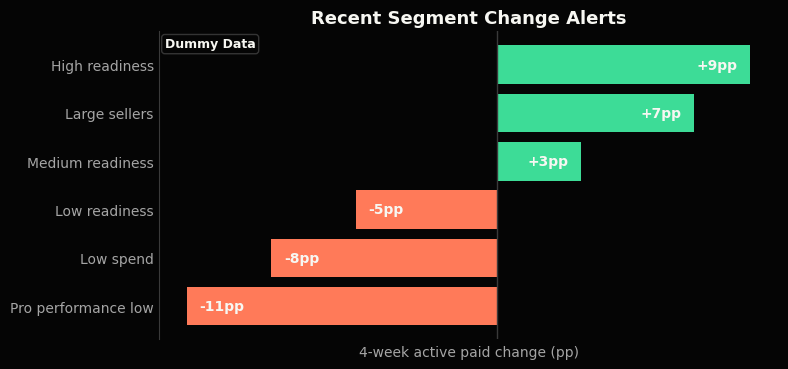

In [22]:
functions.plot_q3_mock_smb_fit_seller_size()
plt.show()

## 3. Business Impact

**Business question:** are bundles creating incremental value for Marktplaats and sellers?

**Dashboard view:** high-value modules needed to complete the impact story.

**What current data supports:** launch traction, paid-base development, modeled paid revenue, and early paid quality.

**What placeholders show:** the visual each missing-data module should contain and the extra data required to build it. Modeled Paid Revenue is a real metric from the current dataset; Net Revenue Impact remains a mockup because offsets such as lost feature revenue, lost CPC revenue, refunds, and cannibalization are not in this file.

**Limitation:** current registration data cannot prove incrementality, seller value uplift, or marketplace quality impact.

### 3.1 Data Requirements

High-value missing-data modules, the visual each would use, and the data required to build them.

In [23]:
display(Markdown(functions.q3_markdown_table(functions.q3_business_impact_placeholder_table())))

| Module | Business question | Placeholder visual |
| --- | --- | --- |
| Revenue impact | Is bundle revenue incremental? | Revenue waterfall: new bundle revenue, lost feature/CPC revenue, net impact |
| Seller value | Do sellers get better outcomes? | Indexed before/after line for leads per active ad |
| Sales steering | Where should launch effort focus? | Compact segment table by category, seller size, spend tier, and outreach batch |

### 3.2 Impact Visual Mockup

**Purpose:** show the net-revenue view needed to complete the business-impact story.

**Important:** the visual below uses dummy data only. Modeled Paid Revenue is already calculated from the current dataset; this net-impact mockup requires additional offset data.

##### Modeled Net Revenue Impact per 4-Week Period

**What is shown:** dummy 4-week bundle revenue gains next to potential revenue offsets such as lost feature revenue, lost CPC revenue, refunds, and credits.

**Why it matters:** this is the missing business-impact view. It moves from gross modeled paid revenue to net value, but it cannot be calculated from the current registrations file alone.

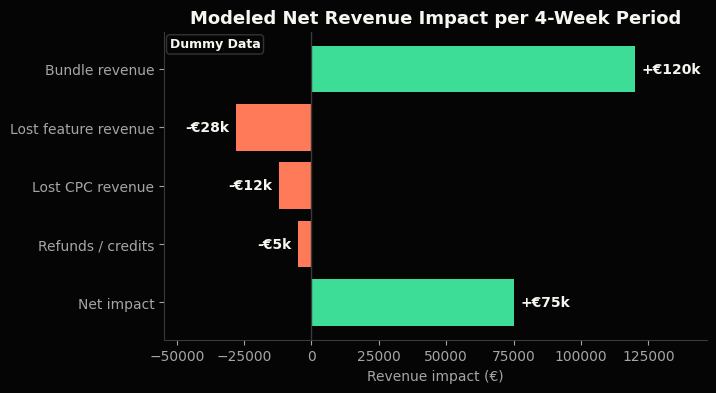

In [24]:
functions.plot_q3_mock_revenue_impact_waterfall()
plt.show()